In [14]:
from pathlib import Path
import os, sys

# Set your project root (adjust if your notebook is not inside the project folder)
PROJECT_ROOT = Path(r"D:\My Downloads\AstroShield_project").resolve()
DATA_TRAIN = PROJECT_ROOT / "data" / "raw" / "train"
DATA_TEST  = PROJECT_ROOT / "data" / "raw" / "test"
RUNS_DIR   = PROJECT_ROOT / "runs"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("TRAIN folder  :", DATA_TRAIN.exists(), DATA_TRAIN)
print("TEST folder   :", DATA_TEST.exists(), DATA_TEST)
print("runs folder   :", RUNS_DIR)


PROJECT_ROOT : D:\My Downloads\AstroShield_project
TRAIN folder  : True D:\My Downloads\AstroShield_project\data\raw\train
TEST folder   : True D:\My Downloads\AstroShield_project\data\raw\test
runs folder   : D:\My Downloads\AstroShield_project\runs


In [15]:
# Lists and counts so you can confirm files are present
def list_files(p, n=10):
    p = Path(p)
    files = list(p.rglob("*.*"))
    print(f"{p} -> {len(files)} files. Showing up to {n}:")
    for f in files[:n]:
        print(" ", f.relative_to(p.parent))

list_files(DATA_TRAIN)
list_files(DATA_TEST)


D:\My Downloads\AstroShield_project\data\raw\train -> 4206 files. Showing up to 10:
  train\train_1\train1\images\000000000_light_cluttered.png
  train\train_1\train1\images\000000003_cluttered_room.png
  train\train_1\train1\images\000000003_light_cluttered.png
  train\train_1\train1\images\000000003_light_uncluttered.png
  train\train_1\train1\images\000000004_cluttered_hallway.png
  train\train_1\train1\images\000000006_light_cluttered.png
  train\train_1\train1\images\000000006_light_cluttered_room.png
  train\train_1\train1\images\000000008_cluttered_hallway.png
  train\train_1\train1\images\000000008_cluttered_room.png
  train\train_1\train1\images\000000009_light_cluttered_room.png
D:\My Downloads\AstroShield_project\data\raw\test -> 2816 files. Showing up to 10:
  test\test3\images\000000000_light_unclutter.png
  test\test3\images\000000000_vdark_clutter.png
  test\test3\images\000000000_vlight_unclutter.png
  test\test3\images\000000001_dark_clutter.png
  test\test3\images\000

Train samples:
Image: 000000000_light_cluttered.png


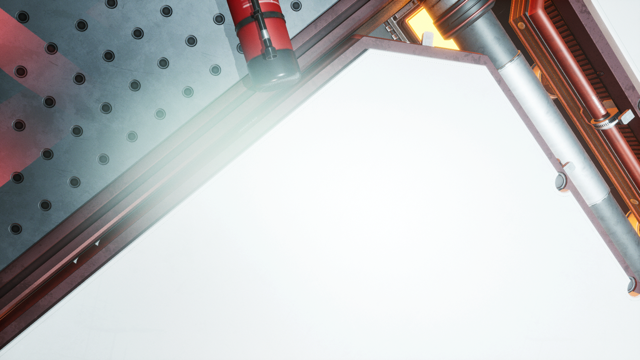

Image: 000000003_cluttered_room.png


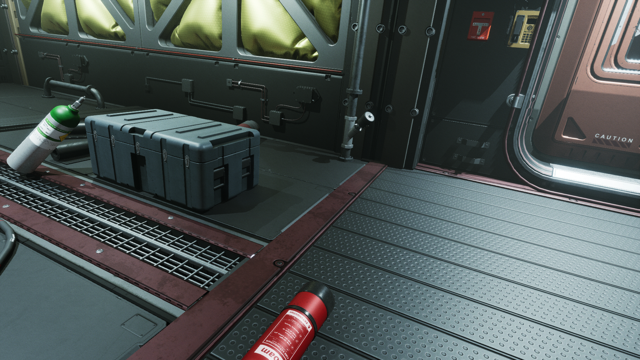

Image: 000000003_light_cluttered.png


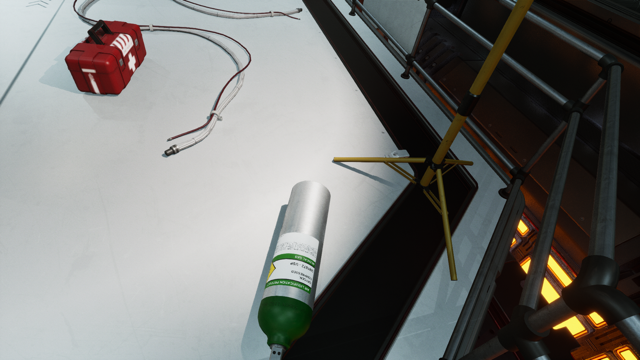

Test samples:
Image: 000000000_light_unclutter.png


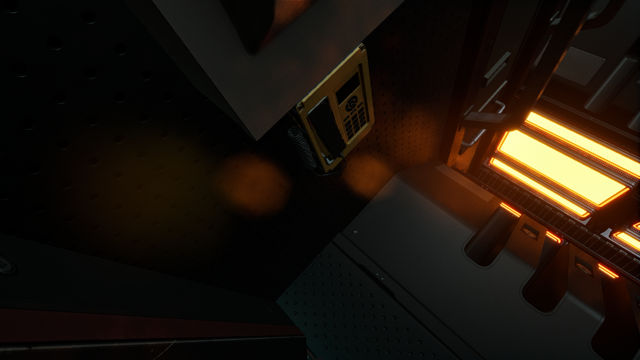

Image: 000000000_vdark_clutter.png


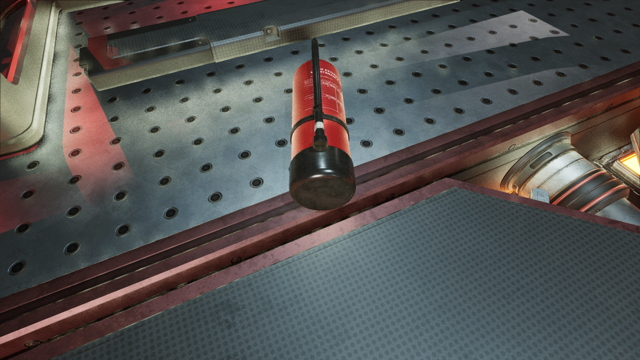

Image: 000000000_vlight_unclutter.png


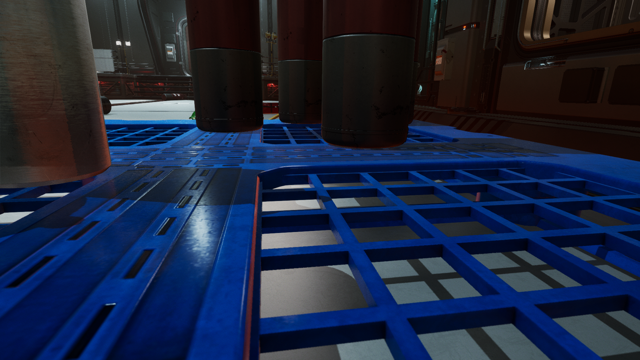

In [16]:
from IPython.display import display
from PIL import Image

def show_sample(p):
    p = Path(p)
    imgs = [f for f in p.rglob("*") if f.suffix.lower() in [".jpg",".jpeg",".png"]]
    if not imgs:
        print("No images in", p)
        return
    for img in imgs[:3]:
        print("Image:", img.name)
        display(Image.open(img).resize((640,360)))

print("Train samples:")
show_sample(DATA_TRAIN)
print("Test samples:")
show_sample(DATA_TEST)


In [ ]:
dataset_yaml = PROJECT_ROOT / "data" / "dataset.yaml"
dataset_yaml.parent.mkdir(parents=True, exist_ok=True)

# EDIT this list: put your class names in the correct order (index 0,1,...)
NAMES = ["class0","class1"]  # <-- REPLACE with your actual class names (example: ["satellite","debris","rocket"])

content = f"train: {DATA_TRAIN.as_posix()}\nval:   {DATA_TEST.as_posix()}\nnc: {len(NAMES)}\nnames: {NAMES}\n"

dataset_yaml.write_text(content)
print("Written dataset yaml to:", dataset_yaml)
print(dataset_yaml.read_text())


Written dataset yaml to: D:\My Downloads\AstroShield_project\data\dataset.yaml
train: D:/My Downloads/AstroShield_project/data/raw/train
val:   D:/My Downloads/AstroShield_project/data/raw/test
nc: 2
names: ['class0', 'class1']



In [20]:
from IPython.display import Image, display
import glob

exp_dir = PROJECT_ROOT / "runs" / "train_experiment"
print("Experiment dir expected:", exp_dir)
weights = list((exp_dir / "weights").glob("*.pt")) if (exp_dir / "weights").exists() else list((exp_dir).glob("*.pt"))
print("Weights found:", weights)

# show results image if exists
res_img = exp_dir / "results.png"
if not res_img.exists():
    # common alternative paths
    gif = list(exp_dir.rglob("results*.png"))
    res_img = gif[0] if gif else None

if res_img and res_img.exists():
    display(Image(res_img))
else:
    print("No results image found at", res_img)


Experiment dir expected: D:\My Downloads\AstroShield_project\runs\train_experiment
Weights found: []
No results image found at None


In [22]:
from pathlib import Path
PROJECT_ROOT = Path(r"D:\My Downloads\AstroShield_project").resolve()
DATA_TRAIN = PROJECT_ROOT / "data" / "raw" / "train"
DATA_TEST  = PROJECT_ROOT / "data" / "raw" / "test"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN exists:", DATA_TRAIN.exists(), DATA_TRAIN)
print("TEST  exists:", DATA_TEST.exists(), DATA_TEST)


PROJECT_ROOT: D:\My Downloads\AstroShield_project
TRAIN exists: True D:\My Downloads\AstroShield_project\data\raw\train
TEST  exists: True D:\My Downloads\AstroShield_project\data\raw\test


In [23]:
from pathlib import Path
PROJECT_ROOT = Path(r"D:\My Downloads\AstroShield_project").resolve()
DATA_TRAIN = PROJECT_ROOT / "data" / "raw" / "train"
DATA_TEST  = PROJECT_ROOT / "data" / "raw" / "test"
dataset_yaml = PROJECT_ROOT / "data" / "dataset.yaml"

NAMES = ['OxygenTank','NitrogenTank','FirstAidBox','FireAlarm','SafetySwitchPanel','EmergencyPhone','FireExtinguisher']

dataset_yaml.parent.mkdir(parents=True, exist_ok=True)
content = f"train: {DATA_TRAIN.as_posix()}\nval:   {DATA_TEST.as_posix()}\nnc: {len(NAMES)}\nnames: {NAMES}\n"
dataset_yaml.write_text(content)
print("Wrote dataset yaml ->", dataset_yaml)
print()
print(dataset_yaml.read_text())


Wrote dataset yaml -> D:\My Downloads\AstroShield_project\data\dataset.yaml

train: D:/My Downloads/AstroShield_project/data/raw/train
val:   D:/My Downloads/AstroShield_project/data/raw/test
nc: 7
names: ['OxygenTank', 'NitrogenTank', 'FirstAidBox', 'FireAlarm', 'SafetySwitchPanel', 'EmergencyPhone', 'FireExtinguisher']



In [24]:
from pathlib import Path
import re, collections
PROJECT_ROOT = Path(r"D:\My Downloads\AstroShield_project").resolve()
label_paths = list((PROJECT_ROOT/"data"/"raw").rglob("*.txt"))
print(f"Found {len(label_paths)} .txt label files (searching train/test)...")

used_indices = collections.Counter()
problem_files = []
sample_problems = []

for p in label_paths:
    try:
        txt = p.read_text().strip()
        if not txt:
            continue
        for line in txt.splitlines():
            parts = re.split(r'\s+', line.strip())
            if len(parts) < 1:
                continue
            idx = int(float(parts[0]))
            used_indices[idx] += 1
            if idx < 0 or idx > 6:
                problem_files.append(str(p))
                if len(sample_problems) < 5:
                    sample_problems.append((p, line))
    except Exception as e:
        problem_files.append(str(p))

print("Label indices usage (index:count):")
for k in sorted(used_indices):
    print(k, ":", used_indices[k])

if not used_indices:
    print("No label indices found — maybe label files are missing or empty.")
if problem_files:
    print("\nFiles with out-of-range or unreadable labels (showing up to 10):")
    for f in problem_files[:10]:
        print(" ", f)
    print("\nSample problematic lines:", sample_problems)
else:
    print("\nAll label indices are within 0..6 ✅")


Found 3512 .txt label files (searching train/test)...
Label indices usage (index:count):
0 : 3109
1 : 3313
2 : 1591
3 : 730
4 : 888
5 : 868
6 : 1520

Files with out-of-range or unreadable labels (showing up to 10):
  D:\My Downloads\AstroShield_project\data\raw\scripts\Hackathon2_scripts\classes.txt

Sample problematic lines: []


In [25]:
from pathlib import Path
PROJECT_ROOT = Path(r"D:\My Downloads\AstroShield_project").resolve()
labels = list((PROJECT_ROOT/"data"/"raw").rglob("*.txt"))[:10]
for p in labels:
    print("----", p)
    print(p.read_text()[:400])


---- D:\My Downloads\AstroShield_project\data\raw\scripts\Hackathon2_scripts\classes.txt
OxygenTank
NitrogenTank
FirstAidBox
FireAlarm
SafetySwitchPanel
EmergencyPhone
FireExtinguisher

---- D:\My Downloads\AstroShield_project\data\raw\test\test3\labels\000000000_light_unclutter.txt
5 0.5161458333333333 0.3037037037037037 0.13958333333333334 0.37407407407407406
4 0.4125 0.1962962962962963 0.440625 0.3925925925925926

---- D:\My Downloads\AstroShield_project\data\raw\test\test3\labels\000000000_vdark_clutter.txt
6 0.50390625 0.3449074074074074 0.1046875 0.48055555555555557

---- D:\My Downloads\AstroShield_project\data\raw\test\test3\labels\000000000_vlight_unclutter.txt
0 0.29583333333333334 0.32083333333333336 0.019791666666666666 0.023148148148148147
1 0.27239583333333334 0.27037037037037037 0.03958333333333333 0.020370370370370372
6 0.4231770833333333 0.300462962962963 0.025520833333333333 0.030555555555555555
4 0.26640625 0.14629629629629629 0.018229166666666668 0.05
4 0.6953125 0.

In [26]:
from pathlib import Path
import re, collections
PROJECT_ROOT = Path(r"D:\My Downloads\AstroShield_project").resolve()
label_paths = list((PROJECT_ROOT/"data"/"raw"/"train").rglob("*.txt")) + list((PROJECT_ROOT/"data"/"raw"/"test").rglob("*.txt"))
print(f"Found {len(label_paths)} .txt label files (train+test only)...")

used_indices = collections.Counter()
for p in label_paths:
    try:
        txt = p.read_text().strip()
        if not txt:
            continue
        for line in txt.splitlines():
            parts = re.split(r'\s+', line.strip())
            if len(parts) < 1:
                continue
            idx = int(float(parts[0]))
            used_indices[idx] += 1
    except Exception as e:
        print("Unreadable file:", p)

print("Label indices usage (index:count):")
for k in sorted(used_indices):
    print(k, ":", used_indices[k])


Found 3511 .txt label files (train+test only)...
Label indices usage (index:count):
0 : 3109
1 : 3313
2 : 1591
3 : 730
4 : 888
5 : 868
6 : 1520


In [27]:
from pathlib import Path
PROJECT_ROOT = Path(r"D:\My Downloads\AstroShield_project").resolve()
DATA_TRAIN = PROJECT_ROOT / "data" / "raw" / "train"
DATA_TEST  = PROJECT_ROOT / "data" / "raw" / "test"
dataset_yaml = PROJECT_ROOT / "data" / "dataset.yaml"

NAMES = ['OxygenTank','NitrogenTank','FirstAidBox','FireAlarm','SafetySwitchPanel','EmergencyPhone','FireExtinguisher']

dataset_yaml.parent.mkdir(parents=True, exist_ok=True)
content = f"train: {DATA_TRAIN.as_posix()}\nval:   {DATA_TEST.as_posix()}\nnc: {len(NAMES)}\nnames: {NAMES}\n"
dataset_yaml.write_text(content)
print("Wrote dataset yaml ->", dataset_yaml)
print(dataset_yaml.read_text())


Wrote dataset yaml -> D:\My Downloads\AstroShield_project\data\dataset.yaml
train: D:/My Downloads/AstroShield_project/data/raw/train
val:   D:/My Downloads/AstroShield_project/data/raw/test
nc: 7
names: ['OxygenTank', 'NitrogenTank', 'FirstAidBox', 'FireAlarm', 'SafetySwitchPanel', 'EmergencyPhone', 'FireExtinguisher']



In [28]:
from pathlib import Path
import re, collections
PROJECT_ROOT = Path(r"D:\My Downloads\AstroShield_project").resolve()
train_txts = list((PROJECT_ROOT/"data"/"raw"/"train").rglob("*.txt"))

img_has_class = {i:set() for i in range(7)}
for p in train_txts:
    for line in p.read_text().splitlines():
        parts = re.split(r'\s+', line.strip())
        if not parts: continue
        idx = int(float(parts[0]))
        img_has_class[idx].add(str(p.parent / p.stem))  # image id

print("Images per class (approx):")
for i in range(7):
    print(i, "->", len(img_has_class[i]))


Images per class (approx):
0 -> 939
1 -> 1004
2 -> 588
3 -> 355
4 -> 397
5 -> 375
6 -> 636


In [7]:
!yolo task=detect mode=train model=yolov8s.pt data=data.yaml epochs=30 imgsz=640 batch=8 project=astroshield name=stageA device=cpu


^C


In [10]:
!python validate_best.py

^C


Using model: D:\My Downloads\AstroShield_project\best.pt
Using dataset config: D:\My Downloads\AstroShield_project\data.yaml
Running validation... Please wait.

Ultralytics 8.3.229  Python-3.9.23 torch-2.8.0+cpu CPU (13th Gen Intel Core i5-1335U)
Model summary (fused): 72 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 282.991.9 MB/s, size: 2867.4 KB)

val: Scanning D:\My Downloads\AstroShield_project\data\raw\test\test3\labels.cache... 1408 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1408/1408  0.0s
val: Scanning D:\My Downloads\AstroShield_project\data\raw\test\test3\labels.cache... 1408 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1408/1408  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 1% ──────────── 1/88 49.0s/it 14.7s<1:11:04
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 2% ──────────── 2/88 27.1s/it 28.0s<38:50
    